In [2]:
import pandas as pd
from matplotlib import pyplot as plt


In [3]:
df = pd.read_csv('../../data/raw/chicago_violence_homicides.csv')

In [4]:
df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='object')

C:\Users\dylan\AppData\Local\Temp\ipykernel_15952\3775407928.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  murders_per_month = murders_per_day.resample('M').sum()


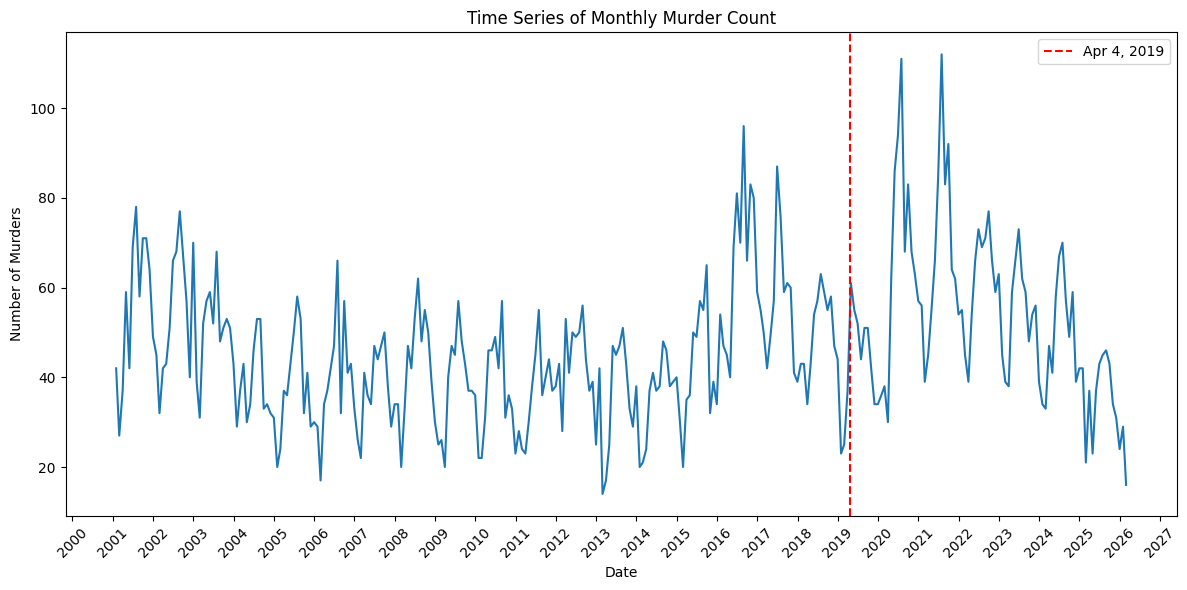

In [12]:
# Convert date column to datetime and sort
df['Date'] = pd.to_datetime(df['Date'])
df_sorted = df.sort_values('Date')

# Count murders per day
murders_per_day = df_sorted.groupby('Date').size()

# Resample to monthly counts
murders_per_month = murders_per_day.resample('M').sum()

# Create the plot (monthly, connected points)
plt.figure(figsize=(12, 6))
plt.plot(murders_per_month.index, murders_per_month.values, linestyle='-')
import matplotlib.dates as mdates
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.axvline(x=pd.to_datetime('2019-04-19'), color='red', linestyle='--', label='Apr 4, 2019')
plt.xlabel('Date')
plt.ylabel('Number of Murders')
plt.title('Time Series of Monthly Murder Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\dylan\AppData\Local\Temp\ipykernel_15952\1207267129.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_before = df_before.groupby(pd.Grouper(key='Date', freq='M')).size()
C:\Users\dylan\AppData\Local\Temp\ipykernel_15952\1207267129.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_after = df_after.groupby(pd.Grouper(key='Date', freq='M')).size()


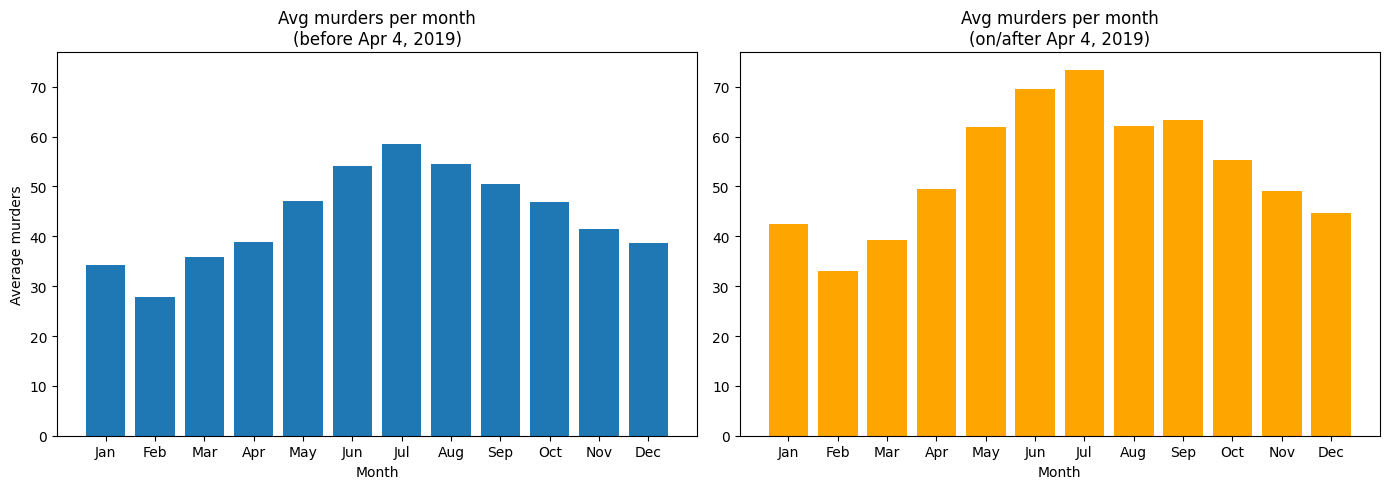

In [16]:
# Compare average murders per calendar month before and after cutoff
cutoff = pd.to_datetime('2019-04-04')
df_before = df_sorted[df_sorted['Date'] < cutoff]
df_after = df_sorted[df_sorted['Date'] >= cutoff]

# Monthly sums for each period
monthly_before = df_before.groupby(pd.Grouper(key='Date', freq='M')).size()
monthly_after = df_after.groupby(pd.Grouper(key='Date', freq='M')).size()

# Average by calendar month (1-12), reindex to ensure all months present
avg_by_month_before = monthly_before.groupby(monthly_before.index.month).mean().reindex(range(1,13), fill_value=0)
avg_by_month_after = monthly_after.groupby(monthly_after.index.month).mean().reindex(range(1,13), fill_value=0)

import calendar
months = [calendar.month_abbr[i] for i in range(1,13)]

plt.figure(figsize=(14,5))
ax1 = plt.subplot(1,2,1)
ax1.bar(months, avg_by_month_before.values)
ax1.set_title('Avg murders per month\n(before Apr 4, 2019)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average murders')

ax2 = plt.subplot(1,2,2)
ax2.bar(months, avg_by_month_after.values, color='orange')
ax2.set_title('Avg murders per month\n(on/after Apr 4, 2019)')
ax2.set_xlabel('Month')

# Use the same y-axis scale for both subplots
ymax = max(avg_by_month_before.max(), avg_by_month_after.max())
ax1.set_ylim(0, ymax * 1.05)
ax2.set_ylim(0, ymax * 1.05)

plt.tight_layout()
plt.show()

In [12]:
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,29047,JK153310,02/17/2026 10:48:00 PM,037XX S LANGLEY AVE,110,HOMICIDE,FIRST DEGREE MURDER,STREET,False,False,...,4.0,36.0,01A,1181414.0,1880308.0,2026,02/25/2026 03:43:24 PM,41.826805,-87.609927,"(41.826804756, -87.609926802)"
1,29046,JK152650,02/17/2026 12:36:00 PM,006XX E 134TH PL,110,HOMICIDE,FIRST DEGREE MURDER,STREET,False,False,...,10.0,54.0,01A,1182937.0,1816224.0,2026,02/25/2026 03:43:24 PM,41.650916,-87.606325,"(41.650915784, -87.606325411)"
2,29045,JK150951,02/15/2026 11:48:00 PM,006XX W 61ST PL,110,HOMICIDE,FIRST DEGREE MURDER,STREET,False,False,...,16.0,68.0,01A,1173092.0,1864111.0,2026,02/23/2026 03:47:05 PM,41.782547,-87.640937,"(41.782546783, -87.640937231)"
3,29044,JK146264,02/11/2026 08:16:00 PM,045XX S ALBANY AVE,110,HOMICIDE,FIRST DEGREE MURDER,APARTMENT,False,True,...,12.0,58.0,01A,1156464.0,1874368.0,2026,02/19/2026 03:42:00 PM,41.811045,-87.701624,"(41.811044665, -87.701624309)"
4,29043,JK145271,02/11/2026 05:03:00 AM,037XX S LAKE PARK AVE,110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,4.0,36.0,01A,1182571.0,1880678.0,2026,02/22/2026 03:41:00 PM,41.827793,-87.605671,"(41.827793249, -87.605670532)"


In [13]:

df_social = pd.read_csv('../../data/raw/chicago_socioeconomic_neighborhoods.csv')

In [14]:
df_social

,Community Area Number,COMMUNITY AREA NAME,PERCENT HOUSEHOLDS BELOW POVERTY,PER CAPITA INCOME,HARDSHIP INDEX
0,1.0,Rogers Park,23.6,23939,39.0
1,2.0,West Ridge,17.2,23040,46.0
2,3.0,Uptown,24.0,35787,20.0
3,4.0,Lincoln Square,10.9,37524,17.0
4,5.0,North Center,7.5,57123,6.0
...,...,...,...,...,...
73,74.0,Mount Greenwood,3.4,34381,16.0
74,75.0,Morgan Park,13.2,27149,30.0
75,76.0,O'Hare,15.4,25828,24.0
76,77.0,Edgewater,18.2,33385,19.0
